In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Đọc dữ liệu
gen_df = pd.read_csv('/kaggle/input/datasets/anikannal/solar-power-generation-data/Plant_1_Generation_Data.csv')
weather_df = pd.read_csv('/kaggle/input/datasets/anikannal/solar-power-generation-data/Plant_1_Weather_Sensor_Data.csv')

# Xử lý định dạng thời gian
gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'], format='%d-%m-%Y %H:%M')
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

# Gộp dữ liệu và gom nhóm 15 phút
df = pd.merge(gen_df.drop(columns=['PLANT_ID', 'SOURCE_KEY']), 
              weather_df.drop(columns=['PLANT_ID', 'SOURCE_KEY']), 
              on='DATE_TIME', how='inner')

df = df.groupby('DATE_TIME').agg({
    'DC_POWER': 'sum',
    'AMBIENT_TEMPERATURE': 'mean',
    'MODULE_TEMPERATURE': 'mean',
    'IRRADIATION': 'mean'
}).reset_index()

print("Kích thước dữ liệu sau khi gộp:", df.shape)

Kích thước dữ liệu sau khi gộp: (3157, 5)


In [2]:
features = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
target = ['DC_POWER']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[target])

def create_sequences(X, y, seq_length):
    xs, ys = [], []
    for i in range(len(X) - seq_length):
        xs.append(X[i:(i + seq_length)])
        ys.append(y[i + seq_length])
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 10 
X_seq, y_seq = create_sequences(X_scaled, y_scaled, SEQ_LENGTH)

train_size = int(len(X_seq) * 0.8)
X_train, y_train = X_seq[:train_size], y_seq[:train_size]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
print("Đã tạo DataLoader thành công. Số batch trong tập Train:", len(train_loader))

Đã tạo DataLoader thành công. Số batch trong tập Train: 79


In [3]:
class SolarLSTM(nn.Module):
    def __init__(self, input_size=3, hidden_size=64, num_layers=2, dropout_prob=0.2):
        super(SolarLSTM, self).__init__()
        # Thêm dropout giữa các tầng LSTM để tăng khả năng tổng quát hóa
        self.lstm = nn.LSTM(
            input_size, 
            hidden_size, 
            num_layers, 
            batch_first=True, 
            dropout=dropout_prob if num_layers > 1 else 0.0
        )
        # Nâng cấp tầng đầu ra thành mạng 2 lớp có kích hoạt ReLU
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :]) 
        return out

def calculate_r2(y_true, y_pred):
    target_mean = torch.mean(y_true)
    ss_tot = torch.sum((y_true - target_mean) ** 2)
    ss_res = torch.sum((y_true - y_pred) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return r2.item()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SolarLSTM(input_size=3, hidden_size=64, num_layers=2).to(device)
criterion = nn.SmoothL1Loss(beta=0.01)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
num_epochs = 50 #
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

print("Sẵn sàng huấn luyện với SmoothL1Loss trên thiết bị:", device)

Sẵn sàng huấn luyện với SmoothL1Loss trên thiết bị: cuda


Bắt đầu huấn luyện...
Epoch [10/50], Loss: 0.037936, R2 Score: 92.65%
Epoch [20/50], Loss: 0.037702, R2 Score: 92.74%
Epoch [30/50], Loss: 0.038354, R2 Score: 92.60%
Epoch [40/50], Loss: 0.037862, R2 Score: 92.65%
Epoch [50/50], Loss: 0.038229, R2 Score: 92.60%
Đã lưu trọng số mô hình thành công tại /kaggle/working/solar_lstm.pth


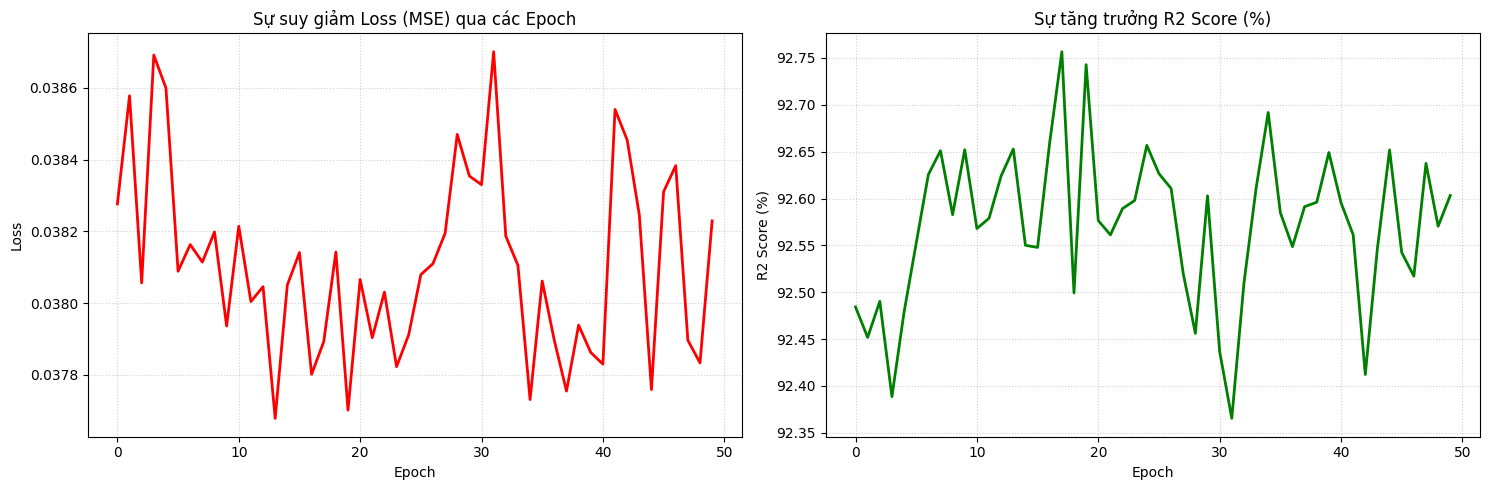

In [6]:
import matplotlib.pyplot as plt

num_epochs = 50
print("Bắt đầu huấn luyện...")

# Khai báo mảng lưu trữ lịch sử
history_loss = []
history_r2 = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    all_preds, all_targets = [], []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
        
        all_preds.append(outputs.detach())
        all_targets.append(y_batch.detach())
        
    train_loss /= len(train_loader.dataset)
    
    all_preds_tensor = torch.cat(all_preds)
    all_targets_tensor = torch.cat(all_targets)
    r2_score = calculate_r2(all_targets_tensor, all_preds_tensor)
    
    # Lưu giá trị vào mảng (thụt lề ngang hàng với các lệnh trong epoch)
    history_loss.append(train_loss)
    history_r2.append(r2_score)
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.6f}, R2 Score: {r2_score * 100:.2f}%')

# Lưu trọng số mô hình
torch.save(model.state_dict(), '/kaggle/working/solar_lstm.pth')
print("Đã lưu trọng số mô hình thành công tại /kaggle/working/solar_lstm.pth")

# Vẽ biểu đồ tổng kết quá trình huấn luyện
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Đồ thị Loss
ax1.plot(history_loss, color='red', linewidth=2)
ax1.set_title("Sự suy giảm Loss (MSE) qua các Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, linestyle=':', alpha=0.6)

# Đồ thị R2 Score
ax2.plot([r * 100 for r in history_r2], color='green', linewidth=2)
ax2.set_title("Sự tăng trưởng R2 Score (%)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("R2 Score (%)")
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [5]:
import os #[cite: 2]
import torch.quantization #[cite: 2]

# Tạo instance mô hình với kiến trúc mới
model_for_quant = SolarLSTM(input_size=3, hidden_size=64, num_layers=2, dropout_prob=0.0)
model_for_quant.load_state_dict(torch.load('/kaggle/working/solar_lstm.pth', map_location='cpu')) #[cite: 2]
model_for_quant.eval() #[cite: 2]

# Lượng tử hóa động các tầng LSTM và Linear
quantized_model = torch.quantization.quantize_dynamic(
    model_for_quant, 
    {nn.LSTM, nn.Linear}, 
    dtype=torch.qint8 #[cite: 2]
)

quantized_model_path = '/kaggle/working/solar_lstm_int8.pth' #[cite: 2]
torch.save(quantized_model.state_dict(), quantized_model_path) #[cite: 2]

size_int8 = os.path.getsize(quantized_model_path) / 1024 #[cite: 2]
print(f"✅ Đã xuất mô hình mới: {quantized_model_path} ({size_int8:.2f} KB)")

✅ Đã xuất mô hình mới: /kaggle/working/solar_lstm_int8.pth (61.60 KB)


/tmp/ipykernel_58/3452081693.py:10: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


/tmp/ipykernel_58/1000033112.py:21: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = torch.quantization.quantize_dynamic(model_int8, {nn.LSTM, nn.Linear}, dtype=torch.qint8)
/usr/local/lib/python3.12/dist-packages/torch/_utils.py:445: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. Thi

Chỉ số đánh giá           | Bản gốc (Float32) | Lượng tử hóa (INT8)
------------------------------------------------------------
Thời gian chạy (ms)       | 138.20          | 35.70          
Sai số MSE                | 0.005258        | 0.005261       
Độ chính xác R2 Score (%) | 92.94           | 92.94          


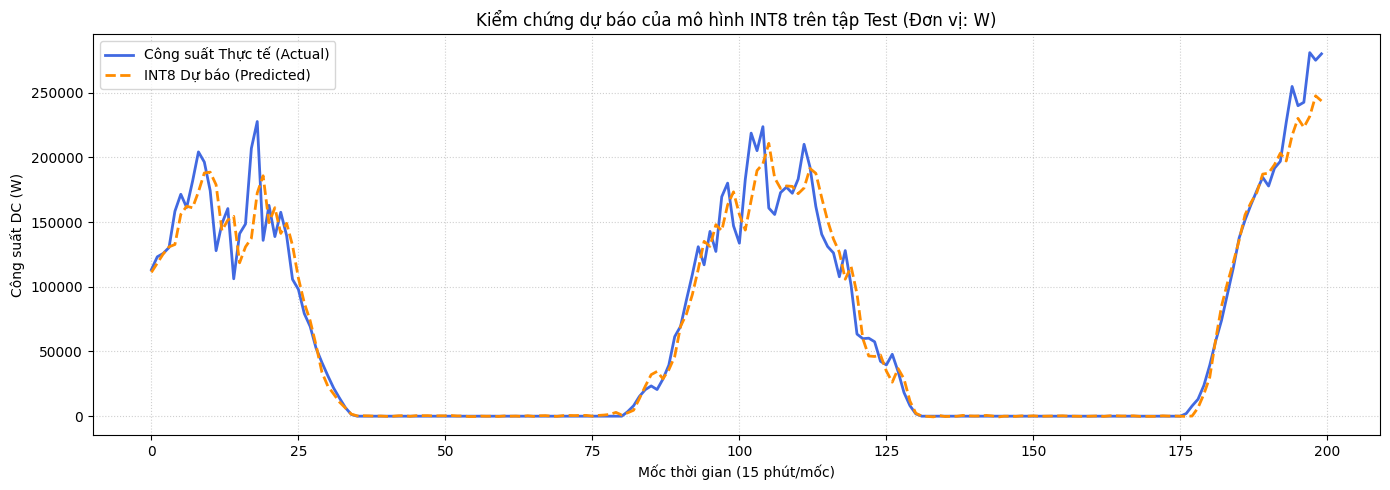

In [7]:
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. Chuẩn bị tập dữ liệu Test (20% còn lại)
X_test = X_seq[train_size:]
y_test = y_seq[train_size:]

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# 2. Tải mô hình gốc Float32 từ file
model_fp32 = SolarLSTM(input_size=3, hidden_size=64, num_layers=2)
model_fp32.load_state_dict(torch.load('/kaggle/working/solar_lstm.pth', map_location='cpu', weights_only=False))
model_fp32.eval()

# 3. Tải mô hình lượng tử hóa INT8 từ file
model_int8 = SolarLSTM(input_size=3, hidden_size=64, num_layers=2)
model_int8 = torch.quantization.quantize_dynamic(model_int8, {nn.LSTM, nn.Linear}, dtype=torch.qint8)
model_int8.load_state_dict(torch.load('/kaggle/working/solar_lstm_int8.pth', map_location='cpu', weights_only=False))
model_int8.eval()
# 4. Đo đạc hiệu năng và độ chính xác
criterion = nn.MSELoss()

# --- Kiểm tra mô hình FP32 ---
t0 = time.time()
with torch.no_grad():
    preds_fp32 = model_fp32(X_test_t)
time_fp32 = (time.time() - t0) * 1000  # ms
loss_fp32 = criterion(preds_fp32, y_test_t).item()
r2_fp32 = calculate_r2(y_test_t, preds_fp32) * 100

# --- Kiểm tra mô hình INT8 ---
t0 = time.time()
with torch.no_grad():
    preds_int8 = model_int8(X_test_t)
time_int8 = (time.time() - t0) * 1000  # ms
loss_int8 = criterion(preds_int8, y_test_t).item()
r2_int8 = calculate_r2(y_test_t, preds_int8) * 100

# In bảng so sánh
print("=" * 60)
print(f"{'Chỉ số đánh giá':<25} | {'Bản gốc (Float32)':<15} | {'Lượng tử hóa (INT8)':<15}")
print("-" * 60)
print(f"{'Thời gian chạy (ms)':<25} | {time_fp32:<15.2f} | {time_int8:<15.2f}")
print(f"{'Sai số MSE':<25} | {loss_fp32:<15.6f} | {loss_int8:<15.6f}")
print(f"{'Độ chính xác R2 Score (%)':<25} | {r2_fp32:<15.2f} | {r2_int8:<15.2f}")
print("=" * 60)

# 5. Khôi phục về đơn vị thực tế (Watts) và vẽ biểu đồ kiểm chứng
actual_watts = scaler_y.inverse_transform(y_test_t.numpy())
pred_watts = scaler_y.inverse_transform(preds_int8.numpy())

plt.figure(figsize=(14, 5))
# Hiển thị 200 điểm dữ liệu đầu tiên của tập Test để quan sát rõ nét chu kỳ ngày/đêm
plt.plot(actual_watts[:200], label="Công suất Thực tế (Actual)", color='royalblue', linewidth=2)
plt.plot(pred_watts[:200], label="INT8 Dự báo (Predicted)", color='darkorange', linestyle='--', linewidth=2)
plt.title("Kiểm chứng dự báo của mô hình INT8 trên tập Test (Đơn vị: W)")
plt.xlabel("Mốc thời gian (15 phút/mốc)")
plt.ylabel("Công suất DC (W)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [8]:
import numpy as np

# 1. Lưu 1 mẫu kiểm thử thực tế
np.save('/kaggle/working/sample_x.npy', X_test[0:1])
np.save('/kaggle/working/sample_y.npy', y_test[0:1])

# 2. In giá trị Min và Max của công suất DC để nạp vào Pi
y_min = float(scaler_y.data_min_[0])
y_max = float(scaler_y.data_max_[0])

print("--- THÔNG SỐ ĐỂ CẤU HÌNH TRÊN PI ---")
print(f"y_min = {y_min}")
print(f"y_max = {y_max}")
print(f"Giá trị chuẩn hóa thực tế: {y_test[0][0]:.6f}")
print(f"Công suất thực tế: {scaler_y.inverse_transform(y_test[0:1])[0][0]:.2f} W")

--- THÔNG SỐ ĐỂ CẤU HÌNH TRÊN PI ---
y_min = 0.0
y_max = 298937.78571
Giá trị chuẩn hóa thực tế: 0.378504
Công suất thực tế: 113149.07 W


In [9]:
print("X_min =", scaler_X.data_min_.tolist()) #[cite: 5]
print("X_max =", scaler_X.data_max_.tolist()) #[cite: 5]
print("y_min =", float(scaler_y.data_min_[0])) #[cite: 5]
print("y_max =", float(scaler_y.data_max_[0])) #[cite: 5]

X_min = [20.398504866666663, 18.140415466666663, 0.0]
X_max = [35.25248613333334, 65.54571366666664, 1.2216518466666668]
y_min = 0.0
y_max = 298937.78571
